In [1]:
import decoupler as dc
import numpy as np
import pandas as pd
import pertpy as pt
import scanpy as sc

c:\Users\asd123cheese\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata_pb = sc.read_h5ad("../data_processed/pseudobulk.h5ad")

In [3]:
adata_pb.layers['counts'] = adata_pb.X.copy()

sc.pp.normalize_total(adata_pb, target_sum=1e5)
sc.pp.log1p(adata_pb)
sc.pp.scale(adata_pb, max_value=10)
sc.tl.pca(adata_pb)

dc.pp.swap_layer(adata=adata_pb, key="counts", inplace=True)

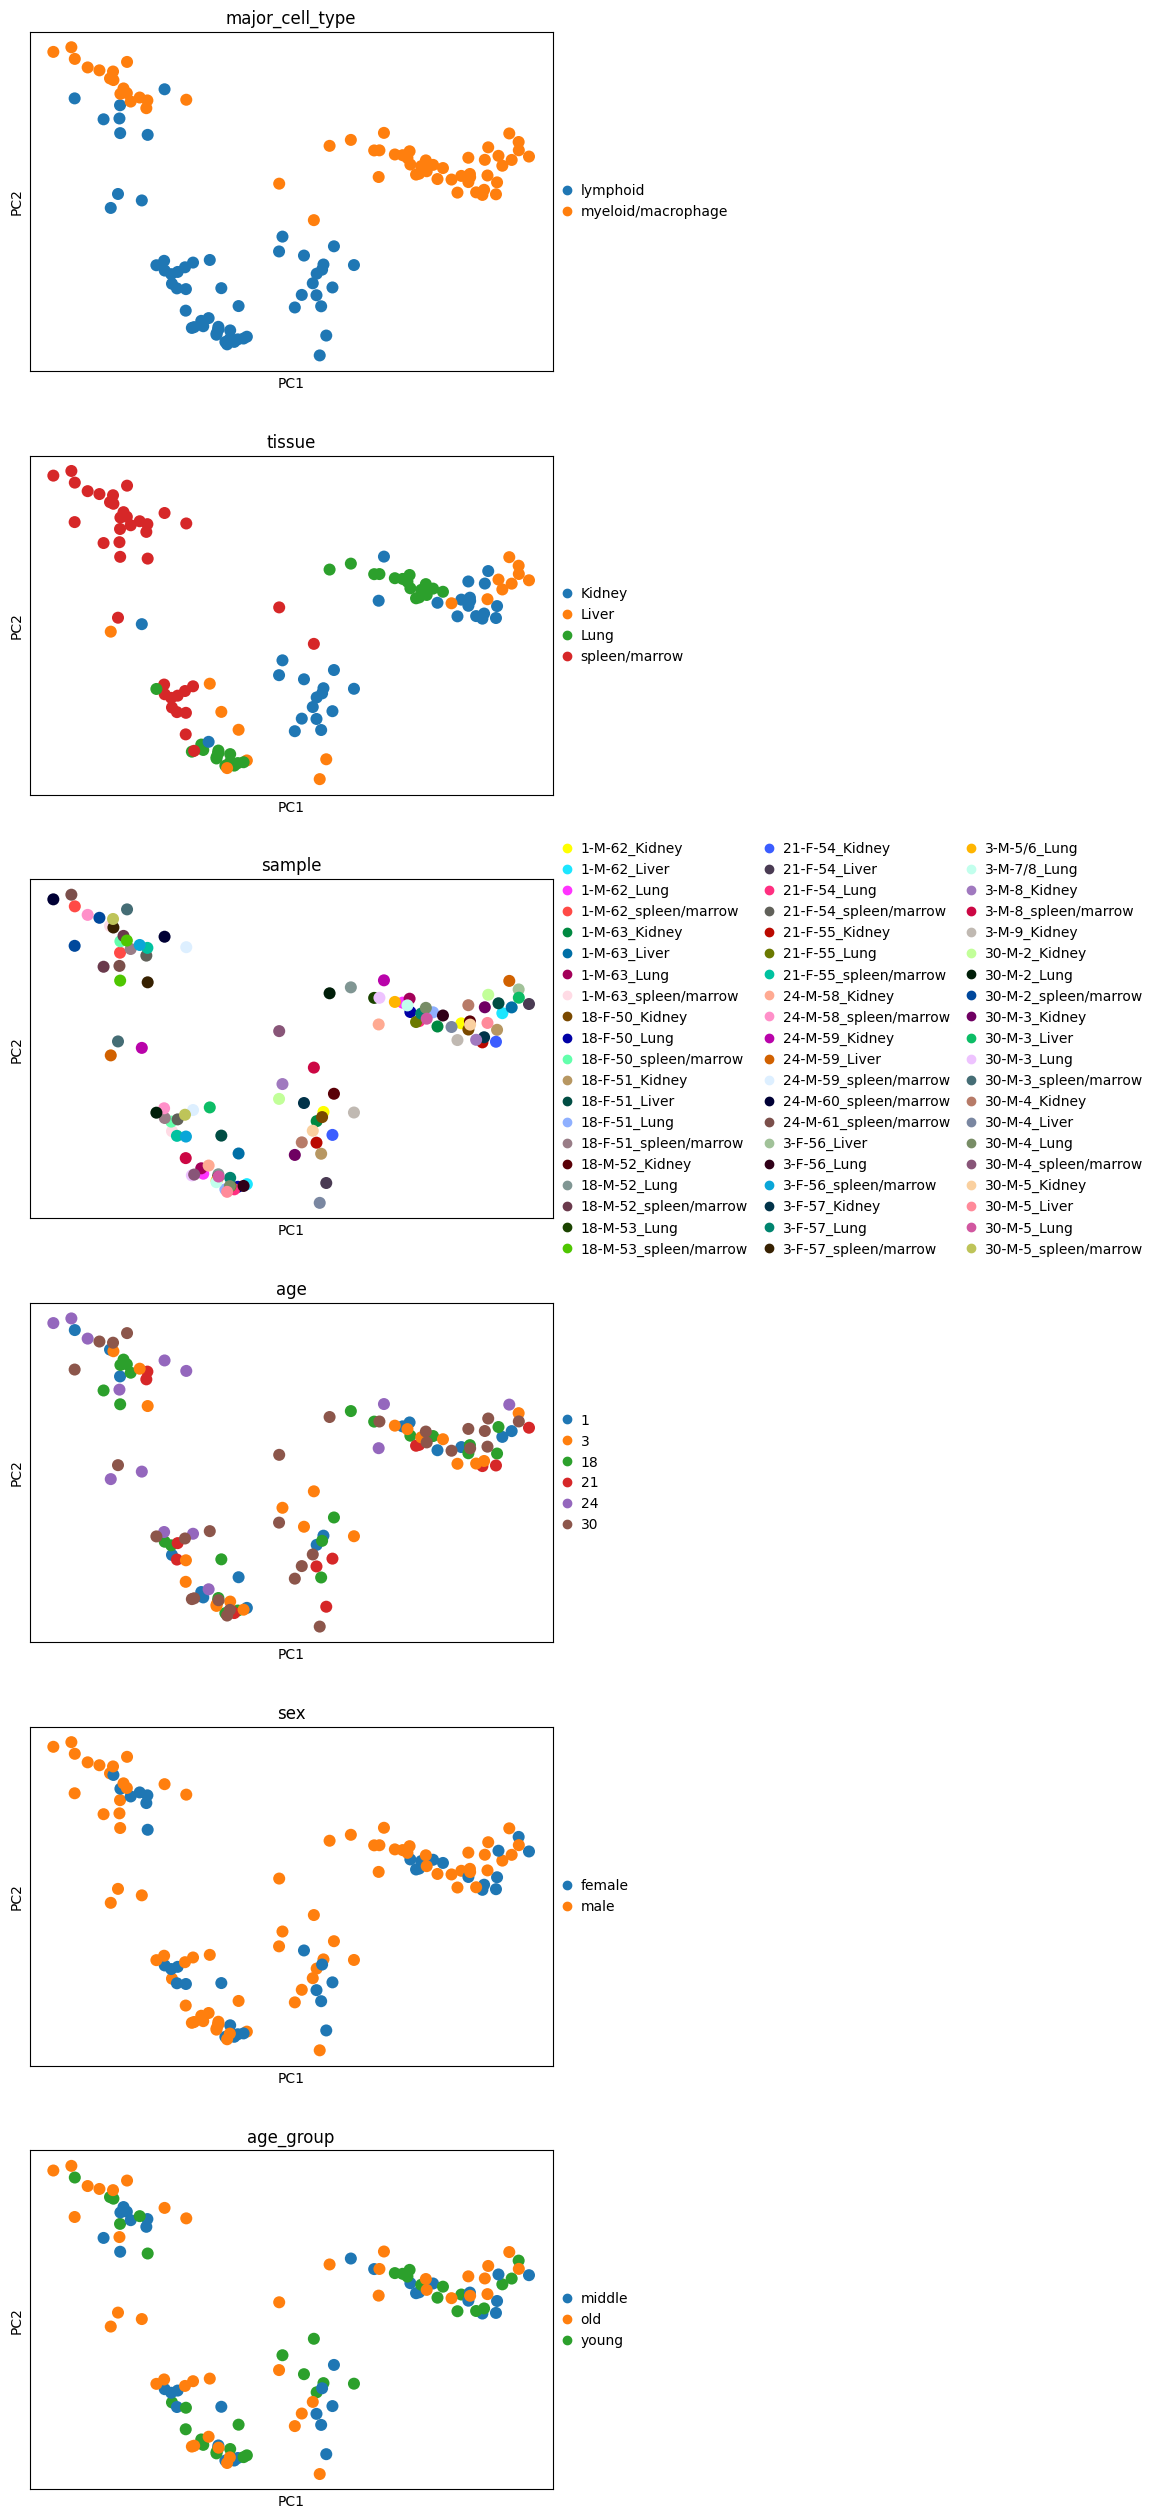

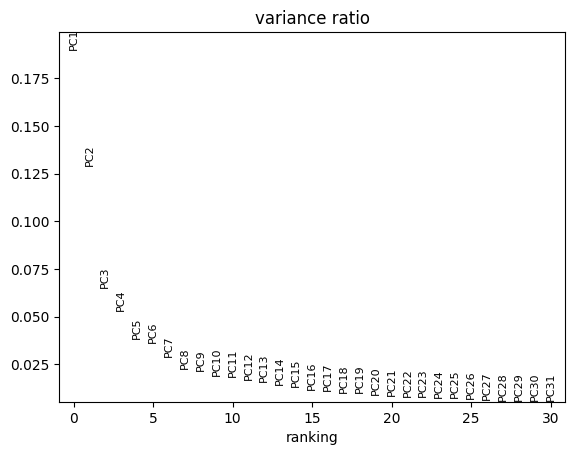

In [4]:
sc.pl.pca(adata_pb, color=['major_cell_type','tissue','sample','age','sex','age_group'], ncols=1, size=300)
sc.pl.pca_variance_ratio(adata_pb)

In [5]:
adata_pb.obs["psbulk_counts_log"] = np.log(adata_pb.obs["psbulk_counts"])
adata_pb.obs["psbulk_cells_log"] = np.log(adata_pb.obs["psbulk_cells"])

In [6]:
dc.tl.rankby_obsm(adata_pb, key="X_pca", obs_keys=['major_cell_type','tissue','age_group','sex'])

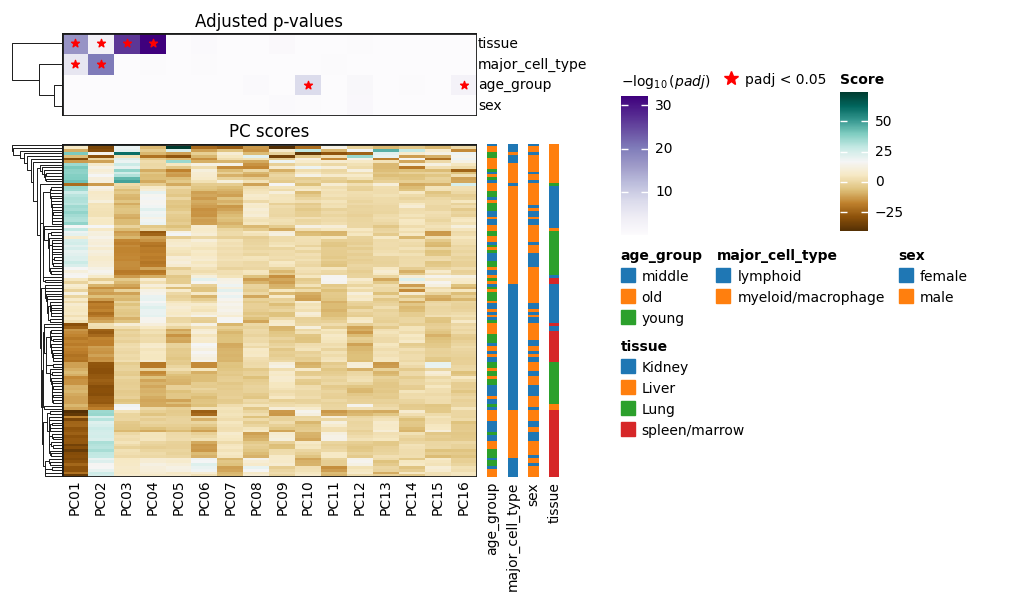

In [7]:
dc.pl.obsm(
    adata_pb,
    return_fig=True,
    nvar=16,
    titles=["PC scores", "Adjusted p-values"],
    figsize=(10, 5)
)

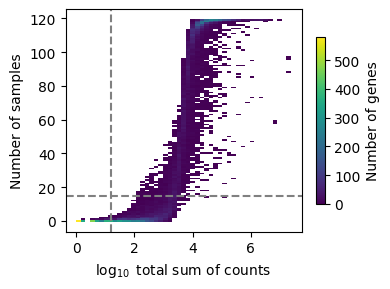

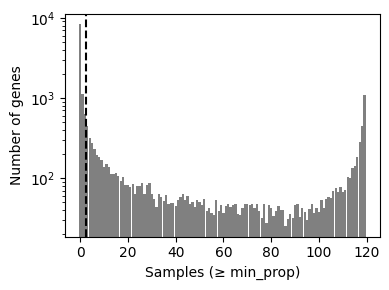

In [9]:
dc.pl.filter_by_expr(
    adata=adata_pb,
    group="tissue",
    min_count=10,
    min_total_count=15,
    large_n=10,
    min_prop=0.7,
)
dc.pl.filter_by_prop(
    adata=adata_pb,
    min_prop=0.1,
    min_smpls=3,
)

In [10]:
dc.pp.filter_by_expr(
    adata=adata_pb,
    group="tissue",
    min_count=10,
    min_total_count=15,
    large_n=10,
    min_prop=0.7,
)
dc.pp.filter_by_prop(
    adata=adata_pb,
    min_prop=0.1,
    min_smpls=3,
)
adata_pb.shape

(119, 9560)

In [11]:
lymphoid = adata_pb[adata_pb.obs["major_cell_type"] == "lymphoid"].copy()

In [12]:
combo_counts = lymphoid.obs.groupby(
    ["tissue", "major_cell_type", "age_group"]
).size().unstack(fill_value=0)
print(combo_counts)

age_group                      middle  old  young
tissue        major_cell_type                    
Kidney        lymphoid              5    6      5
Liver         lymphoid              2    4      2
Lung          lymphoid              6    4      6
spleen/marrow lymphoid              6    8      5


C:\Users\asd123cheese\AppData\Local\Temp\ipykernel_12132\3071607460.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combo_counts = lymphoid.obs.groupby(


In [13]:
import patsy
formula = "~ tissue*age_group*major_cell_type + sex"
design = patsy.dmatrix(formula, data=lymphoid.obs, return_type="dataframe")
rank = np.linalg.matrix_rank(design)
print("列数：", design.shape[1], "秩：", rank)

列数： 13 秩： 13


In [27]:
def DEG(data, formula):
    pds2 = pt.tl.PyDESeq2(data, design=formula)
    pds2.fit()
    res_df = pds2.test_contrasts(
        pds2.contrast(
            column="age_group",
            baseline="young",
            group_to_compare="old",
        )
    )
    return res_df

In [32]:
formula = "~ age_group"
results = {}

for tissue in adata_pb.obs["tissue"].unique():
    for cell_type in adata_pb.obs["major_cell_type"].unique():
        sub = adata_pb[
            (adata_pb.obs["tissue"] == tissue) &
            (adata_pb.obs["major_cell_type"] == cell_type)
        ].copy()
        results[(tissue, cell_type)] = DEG(data=sub, formula=formula)

Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 1.38 seconds.

Fitting dispersion trend curve...
... done in 0.15 seconds.

Fitting MAP dispersions...
... done in 1.38 seconds.

Fitting LFCs...
... done in 1.03 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.50 seconds.

Fitting size factors...
... done in 0.00 seconds.



Log2 fold change & Wald test p-value, contrast vector: [ 0.  1. -1.]
          baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
index                                                                     
Mrpl15   31.698124        0.053942  0.281221  0.191813  0.847889  0.962784
Lypla1   22.843706       -0.127072  0.292632 -0.434239  0.664115  0.910500
Tcea1    42.335676        0.266523  0.255619  1.042657  0.297107  0.705209
Atp6v1h  13.650323        0.017476  0.421734  0.041439  0.966946  0.995025
Rb1cc1   15.316851        0.242660  0.441476  0.549655  0.582556  0.880481
...            ...             ...       ...       ...       ...       ...
Vamp7    11.257769       -0.488693  0.497842 -0.981621  0.326287       NaN
Kdm5d     2.986587        1.002900  0.963595  1.040790  0.297973       NaN
Eif2s3y  24.550648        0.080732  1.328399  0.060774  0.951539  0.991016
Ddx3y    23.373791        0.151593  1.332152  0.113796  0.909400  0.981255
Erdr1    20.001094       -0.562

Fitting dispersions...
... done in 1.26 seconds.

Fitting dispersion trend curve...
... done in 0.14 seconds.

Fitting MAP dispersions...
... done in 1.33 seconds.

Fitting LFCs...
... done in 0.92 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.50 seconds.

Fitting size factors...
... done in 0.00 seconds.



...

Fitting dispersions...
... done in 1.27 seconds.

Fitting dispersion trend curve...
... done in 0.19 seconds.

Fitting MAP dispersions...
... done in 1.54 seconds.

Fitting LFCs...
... done in 1.12 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 4 outlier genes.

Fitting dispersions...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.

Running Wald tests...
... done in 0.53 seconds.

Fitting size factors...
... done in 0.01 seconds.



Log2 fold change & Wald test p-value, contrast vector: [ 0.  1. -1.]
           baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
index                                                                      
Mrpl15   491.979540       -0.083573  0.095557 -0.874589  0.381797  0.914600
Lypla1   316.140395       -0.059989  0.147450 -0.406844  0.684122  0.966521
Tcea1    570.651087       -0.108106  0.131939 -0.819361  0.412581  0.922832
Atp6v1h  138.260681        0.059627  0.125141  0.476477  0.633735  0.958294
Rb1cc1   188.351764       -0.146068  0.260477 -0.560771  0.574954  0.954701
...             ...             ...       ...       ...       ...       ...
Vamp7    142.860505        0.007395  0.222737  0.033200  0.973515  0.996356
Kdm5d     31.877849        0.562657  1.459689  0.385464  0.699894  0.971261
Eif2s3y  267.879875        0.708011  1.819711  0.389079  0.697218  0.970559
Ddx3y    190.453621        0.538242  1.750150  0.307540  0.758432  0.976301
Erdr1    274.249106

Fitting dispersions...
... done in 1.25 seconds.

Fitting dispersion trend curve...
... done in 0.18 seconds.

Fitting MAP dispersions...
... done in 1.47 seconds.

Fitting LFCs...
... done in 0.85 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 13 outlier genes.

Fitting dispersions...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value, contrast vector: [ 0.  1. -1.]
           baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
index                                                                      
Mrpl15   530.003878        0.016219  0.078908  0.205549  0.837143  0.931983
Lypla1   469.277594       -0.024824  0.127214 -0.195135  0.845287  0.934006
Tcea1    643.369410       -0.079365  0.146302 -0.542476  0.587491  0.802469
Atp6v1h  180.118149       -0.116873  0.190087 -0.614839  0.538661  0.772876
Rb1cc1   233.027100        0.447074  0.252394  1.771333  0.076505  0.319752
...             ...             ...       ...       ...       ...       ...
Vamp7    155.823073       -0.194455  0.129577 -1.500695  0.133434  0.414621
Kdm5d     20.828827        0.055609  1.139734  0.048791  0.961086  0.985981
Eif2s3y  331.365009        1.212062  1.807948  0.670407  0.502598  0.748803
Ddx3y    175.811030        0.980626  1.671802  0.586568  0.557494  0.785349
Erdr1    213.983727

... done in 0.45 seconds.



In [35]:
import pickle

with open("../all_results.pkl", "wb") as f:
    pickle.dump(results, f)